# LASSO analysis of PMC sulcal morphology and face recognition (Figure 6, Table S1)

**What it computes.** A fully nested, leave-one-participant-out cross-validated LASSO regression predicting
Cambridge Face Memory Test (CFMT) score from the normalized mean depth of the nine PMC sulci included in the
analysis (the eight sulci present in every hemisphere and the sspls-v), in neurotypical (NT) participants.

**Reproduces** (Results, "A data-driven supervised learning approach..."; Methods, "Behavioral analysis")
* right-hemisphere model: optimal α, RMSE<sub>CV</sub>, selected sulci and their coefficients, selection rate across
  cross-validation folds (Figure 6A, 6B)
* corrected AIC of the selected and full models and ΔAIC; cross-validated adjusted R²
* control models: left hemisphere (depth, NT), right hemisphere with cortical thickness (NT), and both hemispheres in DPs
* bootstrap stability analysis (Table S1): loaded from the saved output of the original 2,000-iteration run

**Inputs** `data/sulcal_depth.csv`, `data/sulcal_thickness.csv` (one row per participant and hemisphere; CFMT and the
nine sulcal values).
**Outputs** `outputs/lasso/` (per-model coefficient and RMSE tables, `model_summary.csv`, `aic_r2.csv`,
`tableS1_bootstrap.csv`, figures).

**How to run.** Start Jupyter from the repository root and run all cells (about 5 minutes). Optional settings,
read from environment variables:
* `RUN_BOOTSTRAP=1` re-runs the bootstrap (`N_BOOTSTRAP`, default 2000; the original run took about 9.5 h).
  The original run used no fixed random seed, so a re-run gives slightly different values from Table S1.
  Re-run results are written to `outputs/lasso/bootstrap/rerun/` and never overwrite the saved results.
* `LASSO_MODELS` (comma-separated) restricts which models are fitted; by default all five are fitted.

**Conventions.** The coefficient reported for each sulcus is the median, across all outer cross-validation folds
(including folds in which the sulcus was not selected, coefficient 0), of the standardized coefficient at the optimal
α. A sulcus is reported as selected when this median is non-zero. RMSE<sub>CV</sub> at each α is the median across
outer folds of the inner leave-one-out cross-validated RMSE. The sulcus called "spls" in the manuscript is labelled
`sbps` in the data.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.preprocessing import StandardScaler

try:                                   # scikit-learn >= 1.4
    from sklearn.metrics import root_mean_squared_error
except ImportError:                    # older scikit-learn
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
print("scikit-learn", sklearn.__version__)

scikit-learn 1.7.2


In [2]:
# ---- settings ----------------------------------------------------------------
REPO = Path.cwd()                      # run from the repository root
assert (REPO / "data" / "sulcal_depth.csv").exists(), "start Jupyter from the repository root"
OUT = REPO / "outputs" / "lasso"
OUT.mkdir(parents=True, exist_ok=True)

SULCI = ["mcgs", "pos", "sbps", "prculs-d", "prcus-p", "prcus-i", "prcus-a", "ifrms", "sspls-v"]
ALPHAS = [round(a, 3) for a in np.logspace(-1, 1, 70)]          # 0.1 to 10
BOOT_ALPHAS = ALPHAS[14:58]                                      # 0.255 to 4.489

# model name -> (morphology file, group, hemisphere)
MODELS = {
    "depth_NT_RH":     ("sulcal_depth.csv",     "Controls", "rh"),   # main model (Figure 6)
    "depth_NT_LH":     ("sulcal_depth.csv",     "Controls", "lh"),   # control: left hemisphere
    "thickness_NT_RH": ("sulcal_thickness.csv", "Controls", "rh"),   # control: cortical thickness
    "depth_DP_RH":     ("sulcal_depth.csv",     "DPs",      "rh"),   # control: DPs
    "depth_DP_LH":     ("sulcal_depth.csv",     "DPs",      "lh"),   # control: DPs
}
RUN_MODELS = [m for m in os.environ.get("LASSO_MODELS", ",".join(MODELS)).split(",") if m]
RUN_BOOTSTRAP = os.environ.get("RUN_BOOTSTRAP", "0") == "1"
N_BOOTSTRAP = int(os.environ.get("N_BOOTSTRAP", "2000"))
loo = LeaveOneOut()


def load_model_data(name):
    fname, group, hemi = MODELS[name]
    d = pd.read_csv(REPO / "data" / fname)
    d = d[["sub", "group", "hemi", "CFMT"] + SULCI].dropna()     # complete cases
    return d[(d.group == group) & (d.hemi == hemi)].reset_index(drop=True)

## Fully nested LASSO

In [3]:
def lasso_fully_nested(X, y, alpha_grid):
    '''Fully nested leave-one-participant-out cross-validated LASSO.

    Outer loop: each participant is held out in turn. Within the training set the predictors are standardized,
    alpha is chosen from `alpha_grid` by an inner leave-one-out grid search that minimizes RMSE, and the model
    is refit at that alpha. Returns per-fold alphas, inner-CV RMSEs and coefficients, and the cross-validated
    R^2 and RMSE of the held-out predictions.
    '''
    Xa, ya = np.asarray(X, float), np.asarray(y, float)
    out = dict(best_alphas=[], best_rmses=[], best_coefs=[], y_test=[], y_pred=[])
    for train, test in loo.split(Xa):
        scaler = StandardScaler()
        Xtr, Xte = scaler.fit_transform(Xa[train]), scaler.transform(Xa[test])
        grid = GridSearchCV(Lasso(max_iter=10000), {"alpha": list(alpha_grid)},
                            scoring="neg_root_mean_squared_error", cv=loo, n_jobs=4)
        grid.fit(Xtr, ya[train])
        model = grid.best_estimator_
        model.fit(Xtr, ya[train])
        out["best_alphas"].append(grid.best_params_["alpha"])
        out["best_rmses"].append(-grid.best_score_)
        out["best_coefs"].append(list(model.coef_))
        out["y_test"] += list(ya[test])
        out["y_pred"] += list(model.predict(Xte))
    out["cv_r2"] = r2_score(out["y_test"], out["y_pred"])
    out["cv_rmse"] = root_mean_squared_error(out["y_test"], out["y_pred"])
    return out


def lasso_alpha_sweep(name, data):
    '''Runs the nested LASSO separately at every alpha in ALPHAS and summarizes across outer folds.'''
    rows = []
    for a in ALPHAS:
        res = lasso_fully_nested(data[SULCI], data["CFMT"], [a])
        for fold, (coefs, rmse) in enumerate(zip(res["best_coefs"], res["best_rmses"])):
            rows += [dict(alpha=a, fold=fold, sulcus=s, beta=b, RMSE=rmse) for s, b in zip(SULCI, coefs)]
    folds = pd.DataFrame(rows)
    rmse = folds.groupby("alpha")["RMSE"].median().reset_index()                 # median across folds
    betas = folds.groupby(["alpha", "sulcus"])["beta"].median().reset_index()     # median across all folds
    sel = (folds.assign(selected=folds.beta != 0)
           .groupby(["alpha", "sulcus"])["selected"].mean().reset_index())
    mdir = OUT / name
    mdir.mkdir(exist_ok=True)
    folds.to_csv(mdir / "fold_coefficients.csv", index=False)
    rmse.to_csv(mdir / "rmse_by_alpha.csv", index=False)
    betas.merge(sel, on=["alpha", "sulcus"]).to_csv(mdir / "median_beta_by_alpha.csv", index=False)
    return folds, rmse, betas, sel

In [4]:
results, summary = {}, []
for name in RUN_MODELS:
    data = load_model_data(name)
    folds, rmse, betas, sel = lasso_alpha_sweep(name, data)
    a_star = float(rmse.loc[rmse.RMSE.idxmin(), "alpha"])
    b = betas[betas.alpha == a_star].set_index("sulcus")["beta"]
    s = sel[sel.alpha == a_star].set_index("sulcus")["selected"]
    results[name] = dict(data=data, rmse=rmse, betas=betas, alpha=a_star)
    summary.append(dict(model=name, n=len(data), alpha=a_star, RMSE_CV=float(rmse.RMSE.min()),
                        selected=", ".join(f"{k} ({v:.2f})" for k, v in b[b != 0].items()) or "none",
                        fold_selection=", ".join(f"{k} {100 * v:.0f}%" for k, v in s[s > 0].items()) or "none"))
summary = pd.DataFrame(summary)
summary.to_csv(OUT / "model_summary.csv", index=False)
summary

,model,n,alpha,RMSE_CV,selected,fold_selection
0,depth_NT_RH,28,1.350,5.207574,"ifrms (-1.29), prcus-i (-0.15), prcus-p (-0.23)","ifrms 100%, mcgs 4%, pos 4%, prcus-i 79%, prcu..."
1,depth_NT_LH,35,2.303,5.484848,none,none
2,thickness_NT_RH,28,4.489,5.440171,none,none
3,depth_DP_RH,16,3.675,4.285714,none,none
4,depth_DP_LH,30,2.154,4.076355,none,none


## Figure 6A and 6B (right-hemisphere depth model, NTs)

In [5]:
%load_ext rpy2.ipython

In [6]:
%%R
suppressPackageStartupMessages({library(ggplot2); library(dplyr)})

# Figure 6A: median standardized coefficient of each sulcus at a range of alpha values
plt_lasso <- function(df) {
  ggplot(df, aes(x = as.factor(alpha), y = as.factor(sulcus))) +
    geom_tile(aes(fill = abs(beta)), linewidth = 0.2) +
    coord_equal() +
    scale_y_discrete(limits = rev(levels(as.factor(df$sulcus)))) +
    scale_fill_gradient(low = "white", high = "#0072B2") +
    geom_text(aes(label = round(beta, digits = 2)), size = 2.7) +
    xlab("α-level") + ylab("PMC Sulci") + labs(fill = "β Weights") +
    theme(axis.text.x = element_text(angle = 40, hjust = 1),
          axis.text = element_text(color = "#333333", size = 11),
          panel.background = element_blank(), aspect.ratio = 10 / 11)
}

# Figure 6B: cross-validated RMSE across alpha values, with the alpha that minimizes it
plt_rmse <- function(df) {
  ggplot(df, aes(x = alpha, y = RMSE)) +
    geom_smooth(color = "#0072B2", span = 0.50, se = FALSE, linewidth = 2, method = "loess",
                formula = y ~ x) +
    geom_vline(xintercept = df$alpha[df$RMSE == min(df$RMSE)], linetype = "dotted", linewidth = 1) +
    xlab("α") + ylab(bquote(RMSE[CV])) +
    theme_classic() +
    theme(axis.text = element_text(color = "#333333", size = 12),
          panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
          aspect.ratio = 10 / 25)
}

In [7]:
if "depth_NT_RH" in results:
    r = results["depth_NT_RH"]
    show_alphas = [round(a, 2) for a in ALPHAS[24:60][::3][:10]]          # the ten alphas shown in Figure 6A
    fig6a = r["betas"].assign(alpha=r["betas"].alpha.round(2))
    fig6a = fig6a[fig6a.alpha.isin(show_alphas)]
    fig6b = r["rmse"]
    fig_dir = str(OUT / "figures")
    os.makedirs(fig_dir, exist_ok=True)

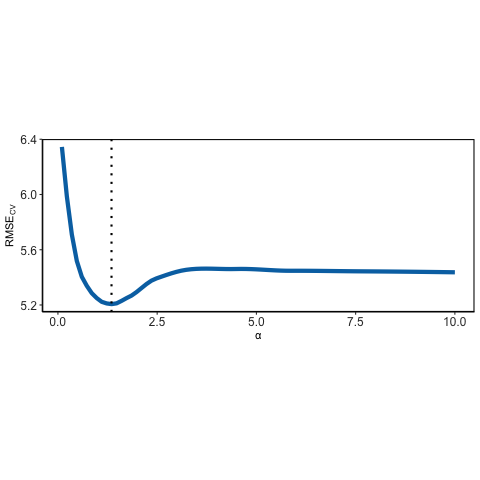

In [8]:
%%R -i fig6a,fig6b,fig_dir
ggsave(file.path(fig_dir, "fig6A_lasso_coefficients.pdf"), plt_lasso(fig6a), width = 7, height = 6)
ggsave(file.path(fig_dir, "fig6B_rmse_cv.pdf"), plt_rmse(fig6b), width = 7, height = 3.5)
print(plt_lasso(fig6a)); print(plt_rmse(fig6b))

## Model comparison (corrected AIC) and cross-validated R² (right-hemisphere depth model, NTs)

AIC<sub>c</sub> = n·log(MSE) + 2K + 2K(K+1)/(n − K − 1), with K = number of sulci + intercept + error variance.
The mean squared error is that of the held-out (leave-one-participant-out) predictions: for the selected model, the
fully nested LASSO at the optimal α (1.35); for the full model, ordinary least squares on all nine sulci. The
cross-validated R² of the selected model uses the same held-out predictions; adjusted R² uses k = 3 selected sulci.

In [9]:
def calculate_aicc(n, rmse, k):
    return n * np.log(rmse ** 2) + 2 * k + (2 * k * (k + 1)) / (n - k - 1)


def linreg_loo(X, y):
    Xa, ya = np.asarray(X, float), np.asarray(y, float)
    pred = np.empty(len(ya))
    for train, test in loo.split(Xa):
        pred[test] = LinearRegression().fit(Xa[train], ya[train]).predict(Xa[test])
    return root_mean_squared_error(ya, pred)


def adj_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)


rh = load_model_data("depth_NT_RH")
n, k_sel = len(rh), 3
alpha_star = results["depth_NT_RH"]["alpha"] if "depth_NT_RH" in results else 1.35
selected = lasso_fully_nested(rh[SULCI], rh["CFMT"], [alpha_star])
aic_sel = calculate_aicc(n, selected["cv_rmse"], k_sel + 2)
aic_full = calculate_aicc(n, linreg_loo(rh[SULCI], rh["CFMT"]), len(SULCI) + 2)
aic = pd.DataFrame([
    dict(quantity="AICc, full model (9 sulci)", value=aic_full),
    dict(quantity=f"AICc, selected model (3 sulci, alpha = {alpha_star})", value=aic_sel),
    dict(quantity="delta AICc (full - selected)", value=aic_full - aic_sel),
    dict(quantity=f"CV R2, alpha = {alpha_star}", value=selected["cv_r2"]),
    dict(quantity=f"CV adjusted R2 (k = 3), alpha = {alpha_star}", value=adj_r2(selected["cv_r2"], n, k_sel)),
])
aic.to_csv(OUT / "aic_r2.csv", index=False)
aic

,quantity,value
0,"AICc, full model (9 sulci)",150.986380
1,"AICc, selected model (3 sulci, alpha = 1.35)",115.619504
2,delta AICc (full - selected),35.366877
3,"CV R2, alpha = 1.35",-0.020468
4,"CV adjusted R2 (k = 3), alpha = 1.35",-0.148027


## Bootstrap stability analysis (Table S1)

Each bootstrap iteration resamples participants with replacement and repeats the full nested pipeline over
`BOOT_ALPHAS`. For each sulcus the table reports the percentage of cross-validation fits (folds × iterations) in
which it was selected, and the median and 2.5th/97.5th percentiles of its coefficient over those fits. Table S1 comes from the saved output of the original 2,000-iteration run
(`outputs/lasso/bootstrap/lasso_bootstrap2000_stats.csv`; the coefficient draws are in
`lasso_bootstrap2000_coefficients.csv.gz`). That run used no fixed random seed.

In [10]:
def bootstrap(n_boot):
    data = {h: load_model_data(f"depth_NT_{h.upper()}") for h in ("rh", "lh")}
    counts = {h: {s: 0 for s in SULCI} for h in data}
    coefs = {h: {s: [] for s in SULCI} for h in data}
    for i in range(n_boot):
        for h, d in data.items():
            r = d.sample(frac=1, replace=True)
            res = lasso_fully_nested(r[SULCI], r["CFMT"], BOOT_ALPHAS)
            for fold_coefs in res["best_coefs"]:
                for s, b in zip(SULCI, fold_coefs):
                    if b != 0:
                        counts[h][s] += 1
                        coefs[h][s].append(b)
    rows = []
    for h, d in data.items():
        for s in SULCI:
            c = coefs[h][s]
            rows.append({"index": s, "Hemi": h.upper(), "Avg Count": round(counts[h][s] / n_boot, 2),
                         "Percentage": round(100 * counts[h][s] / (len(d) * n_boot), 2),
                         "Median Coeff": round(np.median(c), 2) if c else 0,
                         "95% CI Lower": round(np.percentile(c, 2.5), 2) if c else 0,
                         "95% CI Upper": round(np.percentile(c, 97.5), 2) if c else 0})
    return pd.DataFrame(rows)


boot_dir = OUT / "bootstrap"
if RUN_BOOTSTRAP:
    (boot_dir / "rerun").mkdir(parents=True, exist_ok=True)
    boot = bootstrap(N_BOOTSTRAP)
    boot.to_csv(boot_dir / "rerun" / f"lasso_bootstrap{N_BOOTSTRAP}_stats.csv", index=False)
else:
    boot = pd.read_csv(boot_dir / "lasso_bootstrap2000_stats.csv")
table_s2 = (boot[boot.Hemi == "RH"]
            .rename(columns={"index": "Sulcus", "Percentage": "Selected (%)", "Median Coeff": "Median coefficient",
                             "95% CI Lower": "95% CI lower", "95% CI Upper": "95% CI upper"})
            [["Sulcus", "Hemi", "Selected (%)", "Median coefficient", "95% CI lower", "95% CI upper"]]
            .sort_values("Median coefficient"))
table_s2.to_csv(OUT / "tableS1_bootstrap.csv", index=False)
table_s2.round(2)

,Sulcus,Hemi,Selected (%),Median coefficient,95% CI lower,95% CI upper
5,prcus-i,RH,61.28,-1.85,-5.27,-0.15
7,ifrms,RH,86.45,-1.76,-4.41,-0.22
4,prcus-p,RH,56.21,-1.26,-4.41,-0.03
3,prculs-d,RH,53.36,-1.23,-3.89,1.86
6,prcus-a,RH,34.94,-0.78,-4.00,2.45
1,pos,RH,48.59,-0.51,-2.91,2.26
2,sbps,RH,41.31,-0.47,-3.14,3.11
8,sspls-v,RH,43.39,0.04,-1.97,2.86
0,mcgs,RH,34.22,0.14,-2.95,1.89
